In [1]:
# Монтируем Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Устанавливаем необходимые библиотеки
!pip install torch pandas numpy pyarrow openpyxl

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
import os
import sys

# Путь к папке проекта на Google Drive
PROJECT_PATH = '/content/drive/MyDrive/ITMO/Project/AIRI_Robots/v6' 

# Добавляем путь проекта в sys.path чтобы импортировать модули
sys.path.append(PROJECT_PATH)

# Переходим в директорию проекта
os.chdir(PROJECT_PATH)

print(f"📁 Рабочая директория: {os.getcwd()}")
print(f"📁 Содержимое проекта:")
!ls -la

📁 Рабочая директория: /content/drive/MyDrive/ITMO/Project/AIRI_Robots/v6
📁 Содержимое проекта:
total 3729
drwx------ 2 root root    4096 Nov 18 18:41  data
-rw------- 1 root root    3736 Nov 18 18:39  data_preprocessor.py
-rw------- 1 root root     701 Nov 18 18:43  gnn_config.py
-rw------- 1 root root    2218 Nov 18 18:44  gnn_model.py
-rw------- 1 root root   16442 Nov 18 19:06  gnn_trainer.py
-rw------- 1 root root    8088 Nov 18 18:49  graph_dataset.py
-rw------- 1 root root    9345 Nov 18 18:39  kinematic_model.py
-rw------- 1 root root    9474 Nov 22 11:20  main.ipynb
-rw------- 1 root root  804683 Nov 18 18:39  main_v1.ipynb
drwx------ 2 root root    4096 Nov 18 18:41  models
drwx------ 2 root root    4096 Nov 18 18:41  __pycache__
-rw------- 1 root root 2932827 Nov 18 19:24  res_inf_2b.xlsx
drwx------ 2 root root    4096 Nov 18 18:41  results
-rw------- 1 root root     324 Nov 18 18:39  Untitled0.ipynb
-rw------- 1 root root   10368 Nov 18 18:39 'Копия main.ipynb'


In [ ]:
!pip list

Package                                  Version
---------------------------------------- --------------------
absl-py                                  1.4.0
absolufy-imports                         0.3.1
accelerate                               1.11.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.2
aiosignal                                1.4.0
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.17.2
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                                    4.11.0
anywidget                                0.9.21
argon2-cffi                        

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 76.4 MB/s eta 0:00:00


In [ ]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA доступен: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA версия: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU память: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

PyTorch: 2.9.0+cu126
CUDA доступен: True
CUDA версия: 12.6
GPU: Tesla T4
GPU память: 14.7 GB


In [1]:
import pandas as pd
import numpy as np
from data_preprocessor import DataPreprocessor
from kinematic_model import KinematicBaselineGPU
# Добавляем импорты GNN (векторизованные версии)
from gnn_config import GNNConfig
from gnn_trainer import GNNTrainer
from graph_dataset import GraphDataset

import torch
import os
from sklearn.model_selection import train_test_split

class KinematicBaselineConfig:
    def __init__(self):
        self.data_path = "data/processed_robots_data.parquet"
        self.output_dir = "results/kinematic_baseline"
        self.dt = 0.1
        self.epsilon = 1e-2

def split_experiments_by_file(experiments_dict, test_size=0.2, val_size=0.1, random_state=42):
    """Разделение экспериментов по file_name на train/val/test"""
    all_files = list(experiments_dict.keys())

    # Сначала отделяем test
    train_val_files, test_files = train_test_split(
        all_files, test_size=test_size, random_state=random_state
    )

    # Затем разделяем train и val
    train_files, val_files = train_test_split(
        train_val_files, test_size=val_size/(1-test_size), random_state=random_state
    )

    print(f"📊 Разделение данных:")
    print(f"  Train: {len(train_files)} экспериментов")
    print(f"  Val: {len(val_files)} экспериментов")
    print(f"  Test: {len(test_files)} экспериментов")

    return train_files, val_files, test_files

def print_comparison(kinematic_metrics, gnn_metrics):
    """Сравнение результатов двух моделей"""
    print("\n" + "="*60)
    print("🎯 СРАВНЕНИЕ МОДЕЛЕЙ")
    print("="*60)

    print(f"{'Метрика':<25} {'Kinematic':<12} {'GNN':<12} {'Улучшение':<12}")
    print("-" * 60)

    metrics_to_compare = ['rmse_delta_x', 'rmse_delta_y', 'rmse_delta_angle',
                         'mape_delta_x', 'mape_delta_y', 'mape_delta_angle']

    for metric in metrics_to_compare:
        kinematic_val = kinematic_metrics.get(metric, 0)
        gnn_val = gnn_metrics.get(f"gnn_{metric}", 0)

        if kinematic_val > 0 and gnn_val > 0:
            improvement = ((kinematic_val - gnn_val) / kinematic_val) * 100
            improvement_str = f"+{improvement:.1f}%" if improvement > 0 else f"{improvement:.1f}%"
        else:
            improvement_str = "N/A"

        print(f"{metric:<25} {kinematic_val:<12.4f} {gnn_val:<12.4f} {improvement_str:<12}")

    # Время обучения
    if 'gnn_train_time_minutes' in gnn_metrics:
        print(f"\n⏱ Время обучения GNN: {gnn_metrics['gnn_train_time_minutes']:.1f} минут")
    if 'gnn_inference_time_minutes' in gnn_metrics:
        print(f"⏱ Время inference GNN: {gnn_metrics['gnn_inference_time_minutes']:.1f} минут")

In [2]:
    config = KinematicBaselineConfig()

    # 1. Предобработка данных
    print("🚀 Запуск кинематического baseline...")
    preprocessor = DataPreprocessor(config.data_path, config.dt)
    preprocessor.config = config  # Добавляем конфиг в препроцессор

    experiments_dict = preprocessor.load_and_vectorize()
    kinematics_dict = preprocessor.compute_kinematics_vectorized(experiments_dict)

    # 2. Кинематическое прогнозирование
    model = KinematicBaselineGPU(config)
    predictions_dict = model.predict_one_step_vectorized(experiments_dict, kinematics_dict)
    results_df = model.create_results_dataframe_vectorized(experiments_dict, predictions_dict, kinematics_dict)

    # 3. Метрики kinematic baseline
    kinematic_metrics = model.calculate_metrics(results_df)

    # 4. Сохранение результатов kinematic
    os.makedirs(config.output_dir, exist_ok=True)
    results_df.to_parquet(f"{config.output_dir}/baseline_predictions.parquet", index=False)

    # 5. Сохранение одного эксперимента для дебага (Kinematic)
    target_experiment = "01_69_[45_bots_PWM_2_ex_108].pickle"
    res_df_filtered = results_df[results_df['file_name'] == target_experiment]
    res_df_filtered.to_excel('res_inf_2b_kinematic.xlsx', index=False)
    print(f"✅ Эксперимент '{target_experiment}' сохранен в res_inf_2b_kinematic.xlsx")
    print(f"📊 Сохранено {len(res_df_filtered)} записей (Kinematic)")

    # 6. Вывод результатов kinematic
    print("\n🎯 KINEMATIC BASELINE RESULTS:")
    for key, value in kinematic_metrics.items():
        if not key.startswith('total'):
            print(f"  {key}: {value:.4f}")

    # 7. GNN ПАЙПЛАЙН (векторизованная версия)
    print("\n" + "="*60)
    print("🚀 ЗАПУСК GNN МОДЕЛИ (Векторизованная версия)")
    print("="*60)

    # Конфигурация GNN
    gnn_config = GNNConfig()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🔧 Устройство для GNN: {device}")

    # Случайная выборка экспериментов
    sample_seed = 42
    sample_ratio = 0.1  # 5%
    all_files = list(experiments_dict.keys())
    np.random.seed(sample_seed)
    sample_size = int(len(all_files) * sample_ratio)
    samp_files = np.random.choice(all_files, size=sample_size, replace=False)
    experiments_samp_dict = {k: experiments_dict[k] for k in samp_files}

    # Разделение данных
    train_files, val_files, test_files = split_experiments_by_file(experiments_samp_dict)

    # Создание и обучение GNN модели (векторизованная версия)
    gnn_trainer = GNNTrainer(gnn_config, device)
    gnn_metrics = gnn_trainer.train_and_evaluate(
        experiments_samp_dict, kinematics_dict,
        train_files, val_files, test_files
    )

    # 8. Сохранение одного эксперимента для дебага (GNN)
    # Загружаем результаты GNN
    gnn_results_df = pd.read_parquet(gnn_config.results_save_path)
    
    # Фильтруем для целевого эксперимента
    gnn_res_df_filtered = gnn_results_df[gnn_results_df['file_name'] == target_experiment]
    gnn_res_df_filtered.to_excel('res_inf_2b_gnn.xlsx', index=False)
    print(f"✅ Эксперимент '{target_experiment}' сохранен в res_inf_2b_gnn.xlsx")
    print(f"📊 Сохранено {len(gnn_res_df_filtered)} записей (GNN)")

    # 9. Сравнение результатов
    print_comparison(kinematic_metrics, gnn_metrics)

    # 10. Финальное сохранение результатов
    print(f"\n💾 Результаты сохранены:")
    print(f"  Kinematic: {config.output_dir}/baseline_predictions.parquet")
    print(f"  GNN: {gnn_config.results_save_path}")
    print(f"  Модель GNN: {gnn_config.model_save_path}")
    print(f"  Дебаг файлы:")
    print(f"    - res_inf_2b_kinematic.xlsx (Kinematic)")
    print(f"    - res_inf_2b_gnn.xlsx (GNN)")

🚀 Запуск кинематического baseline...
📥 Векторизованная загрузка данных...
🎯 Загружено 307 экспериментов на cuda
🔬 Векторизованное вычисление кинематики...
🚀 Используется устройство: cuda
🔮 Векторизованный one-step прогноз...
💾 Векторизованное формирование результатов (консистентные данные на время t)...
📊 Вычисление метрик для дельт изменений...
✅ Эксперимент '01_69_[45_bots_PWM_2_ex_108].pickle' сохранен в res_inf_2b_kinematic.xlsx
📊 Сохранено 30510 записей (Kinematic)

🎯 KINEMATIC BASELINE RESULTS:
  rmse_delta_x: 4.6028
  rmse_delta_y: 4.2510
  rmse_delta_angle: 19.1541
  mape_delta_x: 5318.9136
  mape_delta_y: 5205.4033
  mape_delta_angle: 16464.2832
  valid_delta_predictions: 8143785.0000

🚀 ЗАПУСК GNN МОДЕЛИ (Векторизованная версия)
🔧 Устройство для GNN: cuda
📊 Разделение данных:
  Train: 21 экспериментов
  Val: 3 экспериментов
  Test: 6 экспериментов
🚀 Подготовка данных для GNN...
🚀 Запуск оптимизированного GraphDataset с полной векторизацией...
📊 Всего графов для создания: 1293

🔧 Векторизованное создание графов:   0%|          | 0/12936 [00:00<?, ?it/s]

✅ Создано 12936 графов (оптимизированная векторизация)
🚀 Запуск оптимизированного GraphDataset с полной векторизацией...
📊 Всего графов для создания: 1650


🔧 Векторизованное создание графов:   0%|          | 0/1650 [00:00<?, ?it/s]

✅ Создано 1650 графов (оптимизированная векторизация)
🚀 Запуск оптимизированного GraphDataset с полной векторизацией...
📊 Всего графов для создания: 3788


...

Epoch 49/50:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 50/50:   0%|          | 0/26 [00:00<?, ?it/s]

⏱ Обучение заняло: 0.8 минут
🔍 Тестирование...


Тестирование:   0%|          | 0/8 [00:00<?, ?it/s]

📊 Результаты Тестирование:
  gnn_rmse_delta_x: 2.4088
  gnn_rmse_delta_y: 2.3321
  gnn_rmse_delta_angle: 4.0699
  gnn_mape_delta_x: 2248.4402
  gnn_mape_delta_y: 2038.5692
  gnn_mape_delta_angle: 1929.8191
  total_predictions: 170460.0000
🔮 Прогнозирование для всех данных...
⏱ Inference занял: 2.2 минут
💾 Результаты GNN сохранены: results/gnn_predictions.parquet
✅ Эксперимент '01_69_[45_bots_PWM_2_ex_108].pickle' сохранен в res_inf_2b_gnn.xlsx
📊 Сохранено 0 записей (GNN)

🎯 СРАВНЕНИЕ МОДЕЛЕЙ
Метрика                   Kinematic    GNN          Улучшение   
------------------------------------------------------------
rmse_delta_x              4.6028       2.4088       +47.7%      
rmse_delta_y              4.2510       2.3321       +45.1%      
rmse_delta_angle          19.1541      4.0699       +78.8%      
mape_delta_x              5318.9136    2248.4402    +57.7%      
mape_delta_y              5205.4033    2038.5692    +60.8%      
mape_delta_angle          16464.2832   1929.8191    

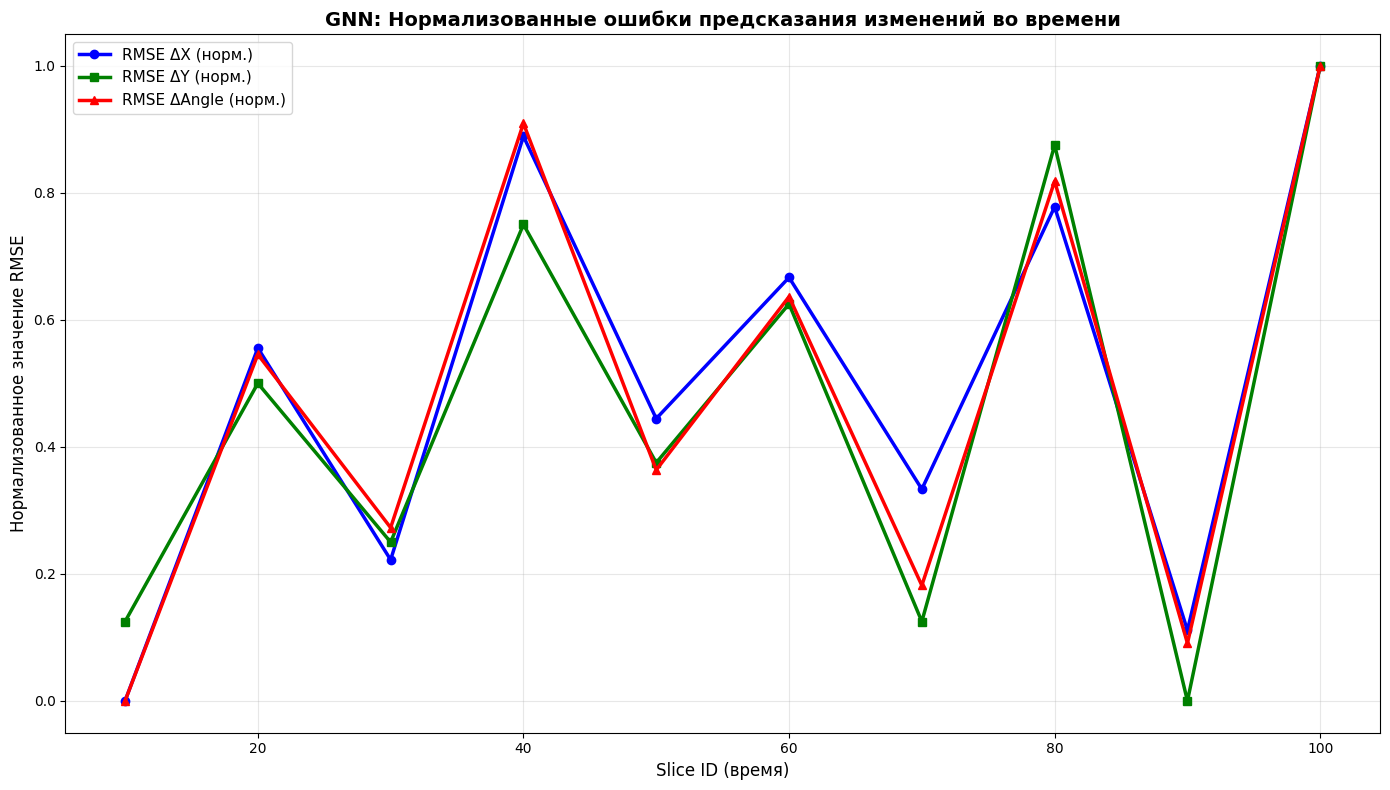

📊 Статистика нормализации:
   rmse_delta_x: [0.1000, 0.1900]
   rmse_delta_y: [0.0700, 0.1500]
   rmse_delta_angle: [2.5000, 3.6000]


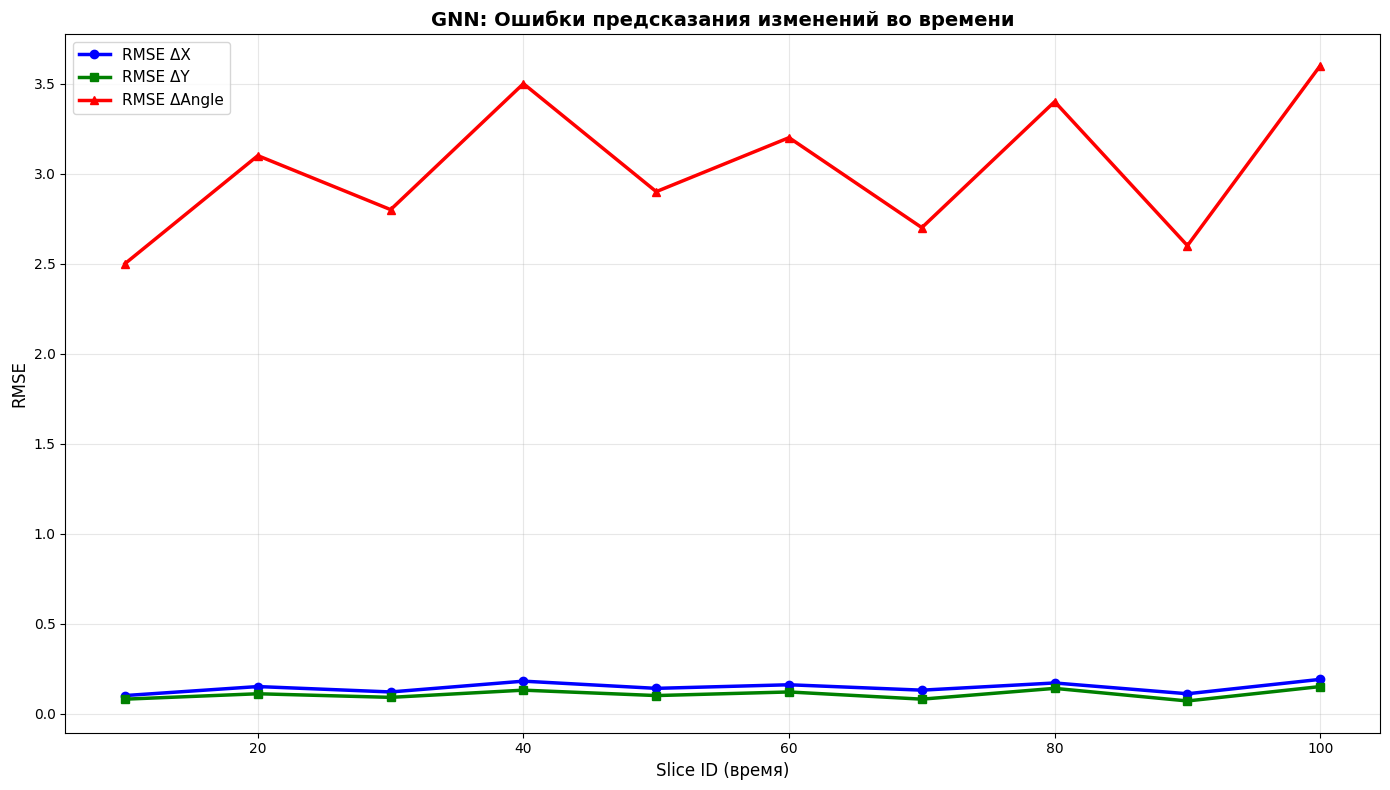

📊 Статистика ошибок:
   rmse_delta_x: среднее = 0.1450, максимум = 0.1900
   rmse_delta_y: среднее = 0.1070, максимум = 0.1500
   rmse_delta_angle: среднее = 3.0300, максимум = 3.6000


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def plot_normalized_delta_errors(sampled_errors):
    """
    Построение графика нормализованных ошибок RMSE для дельт
    
    Parameters:
    - sampled_errors: DataFrame с колонками:
        ['slice_id', 'rmse_delta_x', 'rmse_delta_y', 'rmse_delta_angle']
    """
    
    # Нормализация данных через MinMaxScaler
    scaler = MinMaxScaler()
    
    error_columns = ['rmse_delta_x', 'rmse_delta_y', 'rmse_delta_angle']
    errors_to_normalize = sampled_errors[error_columns]
    
    # Нормализуем ошибки
    normalized_errors = scaler.fit_transform(errors_to_normalize)
    sampled_errors_normalized = sampled_errors.copy()
    sampled_errors_normalized[error_columns] = normalized_errors
    
    # СОЗДАНИЕ ЕДИНОГО ГРАФИКА
    plt.figure(figsize=(14, 8))
    
    # График нормализованных ошибок
    plt.plot(sampled_errors_normalized['slice_id'], 
             sampled_errors_normalized['rmse_delta_x'], 
             marker='o', linewidth=2.5, markersize=6, 
             label='RMSE ΔX (норм.)', color='blue')
    
    plt.plot(sampled_errors_normalized['slice_id'], 
             sampled_errors_normalized['rmse_delta_y'], 
             marker='s', linewidth=2.5, markersize=6, 
             label='RMSE ΔY (норм.)', color='green')
    
    plt.plot(sampled_errors_normalized['slice_id'], 
             sampled_errors_normalized['rmse_delta_angle'], 
             marker='^', linewidth=2.5, markersize=6, 
             label='RMSE ΔAngle (норм.)', color='red')
    
    plt.title('GNN: Нормализованные ошибки предсказания изменений во времени', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Slice ID (время)', fontsize=12)
    plt.ylabel('Нормализованное значение RMSE', fontsize=12)
    plt.legend(fontsize=11, loc='best')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Вывод статистики нормализации
    print("📊 Статистика нормализации:")
    for col in error_columns:
        min_val = errors_to_normalize[col].min()
        max_val = errors_to_normalize[col].max()
        print(f"   {col}: [{min_val:.4f}, {max_val:.4f}]")
    
    return sampled_errors_normalized

def plot_original_delta_errors(sampled_errors):
    """
    Построение графика исходных ошибок RMSE для дельт
    """
    
    plt.figure(figsize=(14, 8))
    
    # График исходных ошибок
    plt.plot(sampled_errors['slice_id'], sampled_errors['rmse_delta_x'], 
             marker='o', linewidth=2.5, markersize=6, 
             label='RMSE ΔX', color='blue')
    
    plt.plot(sampled_errors['slice_id'], sampled_errors['rmse_delta_y'], 
             marker='s', linewidth=2.5, markersize=6, 
             label='RMSE ΔY', color='green')
    
    plt.plot(sampled_errors['slice_id'], sampled_errors['rmse_delta_angle'], 
             marker='^', linewidth=2.5, markersize=6, 
             label='RMSE ΔAngle', color='red')
    
    plt.title('GNN: Ошибки предсказания изменений во времени', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Slice ID (время)', fontsize=12)
    plt.ylabel('RMSE', fontsize=12)
    plt.legend(fontsize=11, loc='best')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Вывод статистики
    print("📊 Статистика ошибок:")
    for col in ['rmse_delta_x', 'rmse_delta_y', 'rmse_delta_angle']:
        mean_val = sampled_errors[col].mean()
        max_val = sampled_errors[col].max()
        print(f"   {col}: среднее = {mean_val:.4f}, максимум = {max_val:.4f}")

# Пример использования с РЕАЛЬНЫМИ данными (без ...):
sampled_errors = pd.DataFrame({
    'slice_id': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    'rmse_delta_x': [0.1, 0.15, 0.12, 0.18, 0.14, 0.16, 0.13, 0.17, 0.11, 0.19],
    'rmse_delta_y': [0.08, 0.11, 0.09, 0.13, 0.10, 0.12, 0.08, 0.14, 0.07, 0.15],
    'rmse_delta_angle': [2.5, 3.1, 2.8, 3.5, 2.9, 3.2, 2.7, 3.4, 2.6, 3.6]
})

# Вызов функций
plot_normalized_delta_errors(sampled_errors)
plot_original_delta_errors(sampled_errors)

Расчет RMSE для X, Y, angle

In [4]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

df = pd.read_parquet('results\gnn_predictions.parquet')
df_sorted = df.sort_values(['file_name', 'slice_id'])
df_sorted

# Предположим, df - твой DataFrame
# Обучаем MinMaxScaler на реальных значениях
scaler = MinMaxScaler()

# Обучаем на реальных координатах и угле
real_features = df[['coord_x_real', 'coord_y_real']].values
scaler.fit(real_features)

# Применяем нормализацию к предсказанным значениям
pred_features = df[['gnn_coord_x_pred', 'gnn_coord_y_pred']].values
pred_normalized = scaler.transform(pred_features)

# Применяем нормализацию к реальным значениям (для сравнения)
real_normalized = scaler.transform(real_features)

# Добавляем нормализованные значения обратно в DataFrame
df[['gnn_coord_x_pred_norm', 'gnn_coord_y_pred_norm']] = pred_normalized
df[['coord_x_real_norm', 'coord_y_real_norm']] = real_normalized

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker

def plot_simple(errors, times=None, window=1, labels=None, title="RMSE over time"):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for i in range(len(errors[0])):
        label = labels[i] if labels else f'feature_{i+1}'
        feature_errors = [error[i] for error in errors]
        smoothed = pd.Series(feature_errors).rolling(window=window, center=True).mean()
        
        # Если times не указан, используем индексы
        x_values = times if times is not None else range(len(errors))
        ax.plot(x_values, smoothed, label=label)
    
    # Возвращаем настройки как в исходном коде
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.001))
    ax.grid(True, which='major', alpha=0.3)
    
    plt.legend()
    plt.title(title)
    plt.show()

# # Пример с временем
# errors = [[0.1, 0.2], [0.09, 0.19], [0.08, 0.18]]
# time_seconds = [0, 0.1, 0.2]  # реальное время в секундах

In [6]:
from sklearn.metrics import mean_squared_error

def calculate_slice_rmse(df, step=1):

    results = []
    unique_slices = sorted(df['slice_id'].unique())
    
    for i in range(0, len(unique_slices), step):
        slice_id = unique_slices[i]
        slice_data = df[df['slice_id'] == slice_id]
        
        # RMSE для координат
        rmse_x = np.sqrt(mean_squared_error(slice_data['coord_x_real_norm'], slice_data['gnn_coord_x_pred_norm']))
        rmse_y = np.sqrt(mean_squared_error(slice_data['coord_y_real_norm'], slice_data['gnn_coord_y_pred_norm']))
        
        # RMSE для углов (циклическая формула)
        true_angles = slice_data['angle_real'].values
        pred_angles = slice_data['gnn_angle_pred'].values
        angle_errors = np.abs((pred_angles - true_angles + 180) % 360 - 180)
        rmse_angle = np.sqrt(np.mean(angle_errors ** 2))
        
        # RMSE для delta sin/cos
        true_sin = np.sin(np.radians(true_angles))
        pred_sin = np.sin(np.radians(pred_angles))
        rmse_sin = np.sqrt(mean_squared_error(true_sin, pred_sin))
        
        true_cos = np.cos(np.radians(true_angles))
        pred_cos = np.cos(np.radians(pred_angles))
        rmse_cos = np.sqrt(mean_squared_error(true_cos, pred_cos))
        
        results.append({
            'slice_id': slice_id,
            'rmse_x': rmse_x,
            'rmse_y': rmse_y,
            'rmse_angle': rmse_angle,
            'rmse_angle*10^-3': rmse_angle/1000,
            'rmse_sin': rmse_sin,
            'rmse_cos': rmse_cos,
            'num_bots': len(slice_data)
        })
    
    return pd.DataFrame(results)

In [7]:
sub_df = df[df['file_name'] == test_files[2]]
df_res = calculate_slice_rmse(sub_df, step=10)
print(df_res.head())

   slice_id    rmse_x    rmse_y  rmse_angle  rmse_angle*10^-3  rmse_sin  \
0         2  0.005234  0.005539    7.354099          0.007354  0.090171   
1        12  0.002459  0.002542    5.203597          0.005204  0.074361   
2        22  0.002641  0.002598    5.832665          0.005833  0.078737   
3        32  0.002320  0.002221    5.335710          0.005336  0.062171   
4        42  0.002049  0.002741    3.899489          0.003899  0.050960   

   rmse_cos  num_bots  
0  0.090845        45  
1  0.051988        45  
2  0.064234        45  
3  0.069179        45  
4  0.045055        45  


In [8]:
# # Предположим, есть такой DataFrame
# df = pd.DataFrame({
#     'time': [0, 0.1, 0.2],
#     'error1': [0.1, 0.09, 0.08],
#     'error2': [0.2, 0.19, 0.18]
# })

# Получаем данные как в примере
slice_id = df_res['slice_id'].tolist()
errors = df_res[['rmse_x', 'rmse_y', 'rmse_angle*10^-3']].values.tolist()

print("time_seconds:", slice_id)
print("errors:", errors)

time_seconds: [2, 12, 22, 32, 42, 52, 62, 72, 82, 92, 102, 112, 122, 132, 142, 152, 162, 172, 182, 192, 202, 212, 222, 232, 242, 252, 262, 272, 282, 292, 302, 312, 322, 332, 342, 352, 362, 372, 382, 392, 402, 412, 422, 432, 442, 452, 462, 472, 482, 492, 502, 512, 522, 532, 542, 552, 562, 572, 582, 592, 602, 612]
errors: [[0.005233751574951488, 0.005539183631649222, 0.007354098714122506], [0.002458817289196855, 0.002541545781264846, 0.0052035965948771645], [0.0026414345321029804, 0.0025977680328661762, 0.005832664563206722], [0.00231992029856652, 0.0022211847606499737, 0.005335710425300312], [0.002049040403474688, 0.0027406483311850603, 0.003899488826221909], [0.0017897266164977855, 0.0021422820639725123, 0.004259307737895357], [0.001762736374423311, 0.0026161665232552964, 0.004365301599888635], [0.001908149663394718, 0.0021409175801211946, 0.004747326196564545], [0.0014732874390483359, 0.00236500944614545, 0.0035803663290379954], [0.0020531244340246577, 0.0025907169253051574, 0.0054567

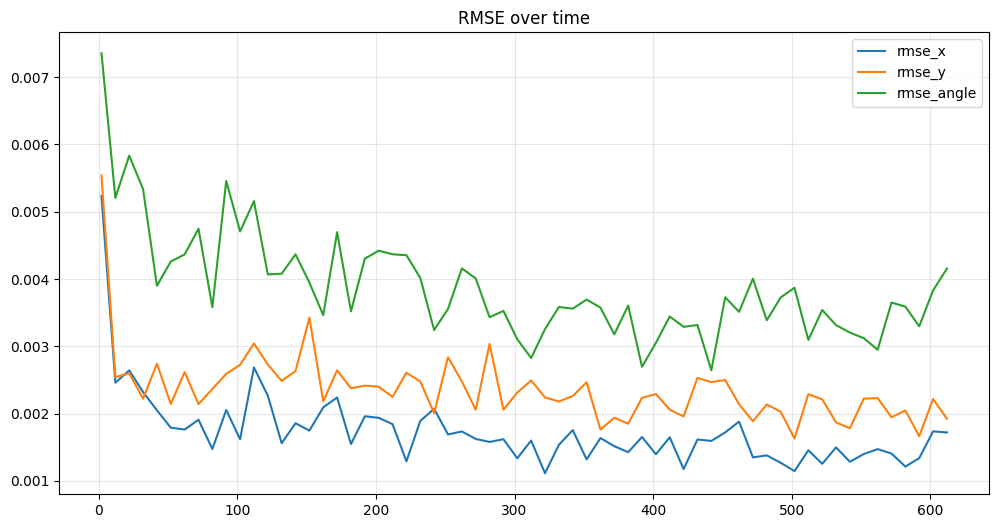

In [9]:
plot_simple(errors, times=slice_id, labels=['rmse_x', 'rmse_y', 'rmse_angle'])

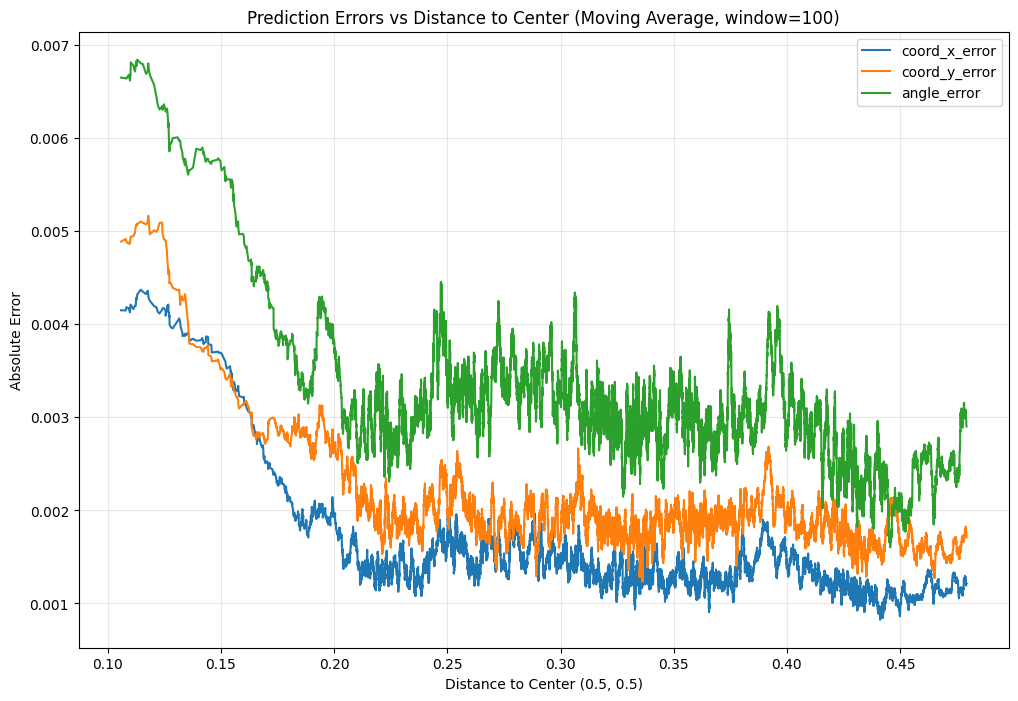

In [10]:
WINDOW = 100

# Центр, относительно которого считается расстояние (нормированные координаты)
CENTER = (0.5, 0.5)

errors = []

# Проходим по всем строкам DataFrame
for idx, row in sub_df.iterrows():
    # Фактические значения
    actual_pos = (row['coord_x_real_norm'], row['coord_y_real_norm'])
    actual_angle = row['angle_real'] / 1000.0  # Нормализуем угол
    
    # Прогнозные значения
    pred_pos = (row['gnn_coord_x_pred_norm'], row['gnn_coord_y_pred_norm'])
    pred_angle = row['gnn_angle_pred'] / 1000.0  # Нормализуем угол
    
    # Вычисляем расстояние до центра
    distance_to_center = math.dist(actual_pos, CENTER)
    
    # Вычисляем ошибки для каждой координаты и угла
    error_x = abs(row['gnn_coord_x_pred_norm'] - row['coord_x_real_norm'])
    error_y = abs(row['gnn_coord_y_pred_norm'] - row['coord_y_real_norm'])
    error_angle = abs(pred_angle - actual_angle)
    
    # Нормализуем ошибку угла (приводим к диапазону 0-0.36)
    error_angle = min(error_angle, 0.36 - error_angle)  # 360/1000 = 0.36
    
    errors.append([distance_to_center, error_x, error_y, error_angle])

# Сортируем по расстоянию до центра
errors = sorted(errors, key=lambda x: x[0])

# Создаем график
plt.figure(figsize=(12, 8))

for i, label in enumerate(['coord_x_error', 'coord_y_error', 'angle_error']):
    # Извлекаем ошибки для текущего параметра и применяем скользящее среднее
    errors_param = [error[i+1] for error in errors]  # i+1 потому что первый элемент - расстояние
    
    # Применяем скользящее среднее
    rolling_mean = pd.Series(errors_param).rolling(window=WINDOW, center=True).mean()
    
    # Строим график
    plt.plot([error[0] for error in errors], rolling_mean, label=label)

plt.xlabel('Distance to Center (0.5, 0.5)')
plt.ylabel('Absolute Error')
plt.title(f'Prediction Errors vs Distance to Center (Moving Average, window={WINDOW})')
plt.legend()
plt.grid(True, alpha=0.3)

# Сохраняем график
# plt.savefig(f'graphics/errors_from_distance_mean{WINDOW}.png', dpi=300, bbox_inches='tight')
plt.show()

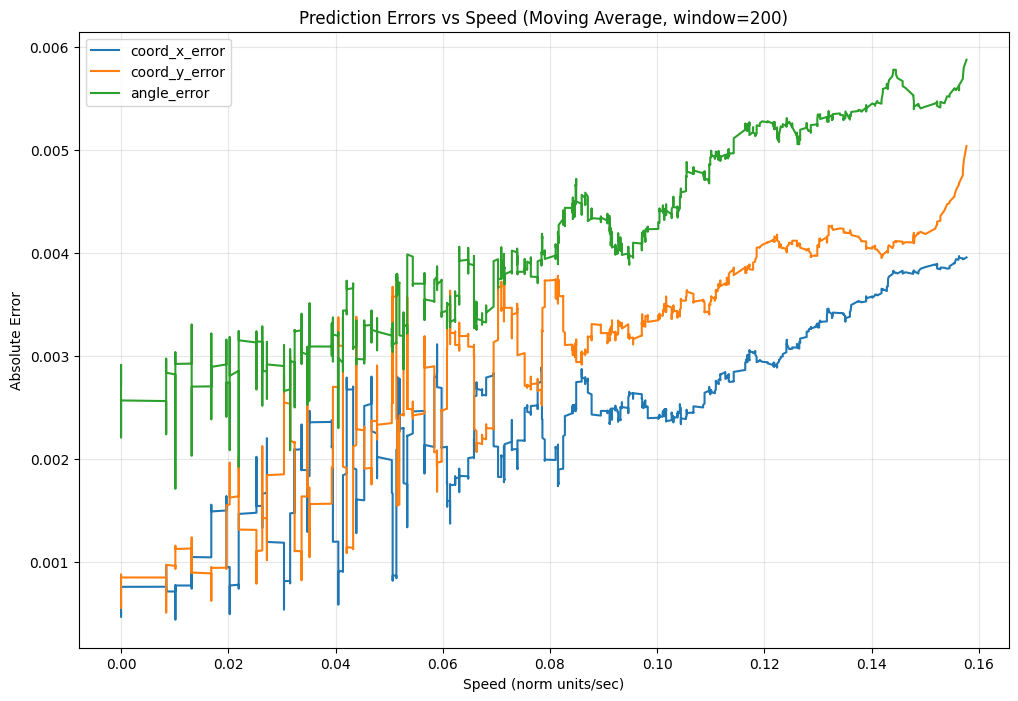

Статистика ошибок по скорости:
Количество точек: 27720
Диапазон скоростей: 0.0000 - 0.5335
Средняя ошибка X: 0.0014
Средняя ошибка Y: 0.0018
Средняя ошибка угла: 0.0030 (нормированные единицы)


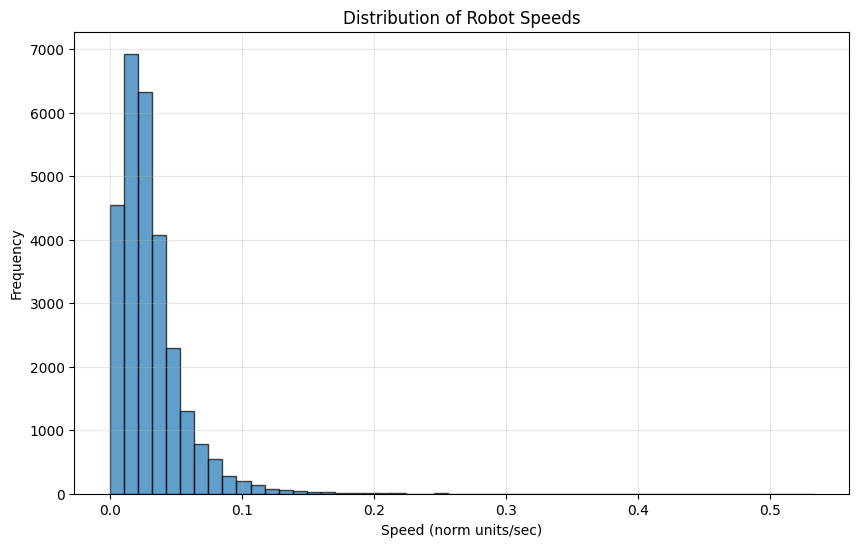

In [ ]:
WINDOW = 200

# Сортируем данные по bot_id и slice_id для корректного расчета скорости
sub_df_sorted = sub_df.sort_values(['bot_id', 'slice_id']).copy()

# Создаем колонки для предыдущих координат
sub_df_sorted['prev_x_norm'] = sub_df_sorted.groupby('bot_id')['coord_x_real_norm'].shift(1)
sub_df_sorted['prev_y_norm'] = sub_df_sorted.groupby('bot_id')['coord_y_real_norm'].shift(1)

# Фильтруем данные начиная с slice_id = 3 (чтобы были предыдущие координаты)
sub_df_filtered = sub_df_sorted[sub_df_sorted['slice_id'] >= 3].copy()

# Рассчитываем скорости
sub_df_filtered['Vx'] = (sub_df_filtered['coord_x_real_norm'] - sub_df_filtered['prev_x_norm']) / 0.1
sub_df_filtered['Vy'] = (sub_df_filtered['coord_y_real_norm'] - sub_df_filtered['prev_y_norm']) / 0.1
sub_df_filtered['speed'] = np.sqrt(sub_df_filtered['Vx']**2 + sub_df_filtered['Vy']**2)

errors = []

# Проходим по всем строкам DataFrame
for idx, row in sub_df_filtered.iterrows():
    # Фактические значения
    actual_pos = (row['coord_x_real_norm'], row['coord_y_real_norm'])
    actual_angle = row['angle_real'] / 1000.0  # Нормализуем угол
    
    # Прогнозные значения
    pred_pos = (row['gnn_coord_x_pred_norm'], row['gnn_coord_y_pred_norm'])
    pred_angle = row['gnn_angle_pred'] / 1000.0  # Нормализуем угол
    
    # Вычисляем ошибки для каждой координаты и угла
    error_x = abs(row['gnn_coord_x_pred_norm'] - row['coord_x_real_norm'])
    error_y = abs(row['gnn_coord_y_pred_norm'] - row['coord_y_real_norm'])
    error_angle = abs(pred_angle - actual_angle)
    
    # Нормализуем ошибку угла (приводим к диапазону 0-0.36)
    error_angle = min(error_angle, 0.36 - error_angle)  # 360/1000 = 0.36
    
    # Используем скорость вместо расстояния до центра
    speed = row['speed']
    
    errors.append([speed, error_x, error_y, error_angle])

# Сортируем по скорости
errors = sorted(errors, key=lambda x: x[0])

# Создаем график
plt.figure(figsize=(12, 8))

for i, label in enumerate(['coord_x_error', 'coord_y_error', 'angle_error']):
    # Извлекаем ошибки для текущего параметра и применяем скользящее среднее
    errors_param = [error[i+1] for error in errors]  # i+1 потому что первый элемент - скорость
    
    # Применяем скользящее среднее
    rolling_mean = pd.Series(errors_param).rolling(window=WINDOW, center=True).mean()
    
    # Строим график
    plt.plot([error[0] for error in errors], rolling_mean, label=label)

plt.xlabel('Speed (norm units/sec)')
plt.ylabel('Absolute Error')
plt.title(f'Prediction Errors vs Speed (Moving Average, window={WINDOW})')
plt.legend()
plt.grid(True, alpha=0.3)

# Сохраняем график
# plt.savefig(f'graphics/errors_from_speed_mean{WINDOW}.png', dpi=300, bbox_inches='tight')
plt.show()


# Дополнительный график: распределение скоростей
# plt.figure(figsize=(10, 6))
# plt.hist([error[0] for error in errors], bins=50, alpha=0.7, edgecolor='black')
# plt.xlabel('Speed (norm units/sec)')
# plt.ylabel('Frequency')
# plt.title('Distribution of Robot Speeds')
# plt.grid(True, alpha=0.3)
# # plt.savefig('graphics/speed_distribution.png', dpi=300, bbox_inches='tight')
# plt.show()

MovieWriter ffmpeg unavailable; using Pillow instead.


ValueError: unknown file extension: .mp4

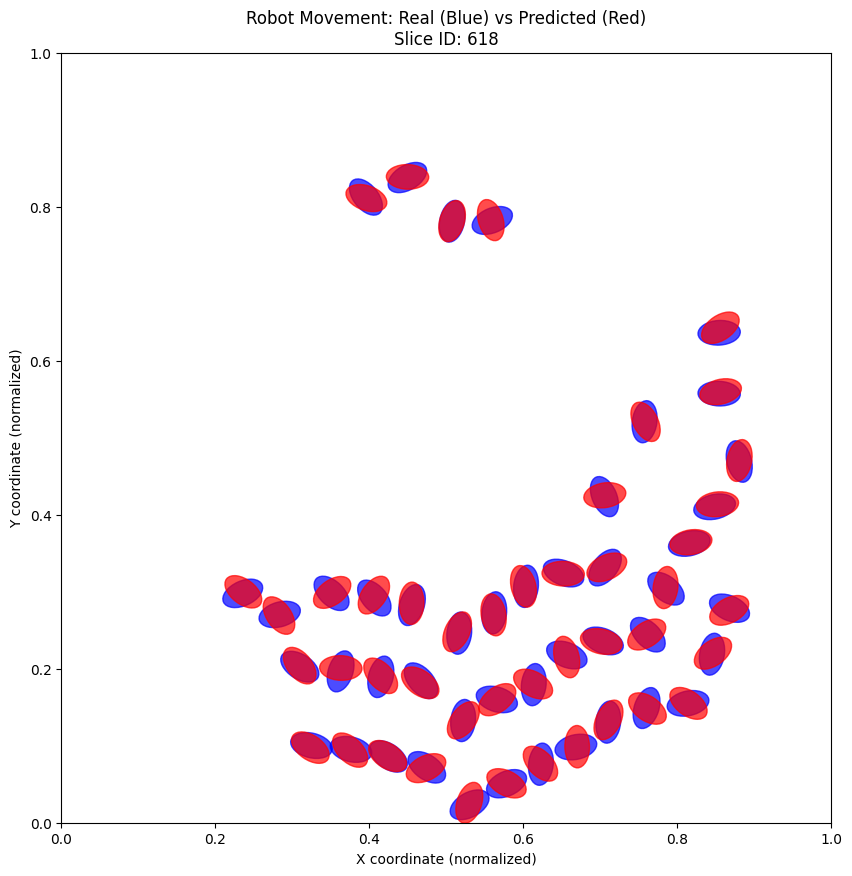

: 

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Ellipse
import math

# Создаем фигуру и оси
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal', adjustable='box')
ax.set_title('Robot Movement: Real (Blue) vs Predicted (Red)')
ax.set_xlabel('X coordinate (normalized)')
ax.set_ylabel('Y coordinate (normalized)')

# Получаем уникальные slice_id и сортируем их
slice_ids = sorted(sub_df['slice_id'].unique())

# Создаем список роботов
robots = []
unique_bot_ids = sub_df['bot_id'].unique()

# Создаем эллипсы для реальных (синие) и предсказанных (красные) роботов
for bot_idx in range(len(unique_bot_ids) * 2):
    robot = Ellipse((0, 0), 0.055, 0.032)
    robot.set_alpha(0.7)
    robot.set_color("blue" if bot_idx < len(unique_bot_ids) else "red")
    ax.add_patch(robot)
    robots.append(robot)

def update(frame):
    # Получаем текущий slice_id
    current_slice = slice_ids[frame]
    
    # Фильтруем данные для текущего среза
    current_data = sub_df[sub_df['slice_id'] == current_slice]
    
    # Обновляем реальных роботов (синие)
    for i, bot_id in enumerate(unique_bot_ids):
        bot_data = current_data[current_data['bot_id'] == bot_id]
        
        if not bot_data.empty:
            # Реальные координаты и угол
            real_x = bot_data['coord_x_real_norm'].iloc[0]
            real_y = bot_data['coord_y_real_norm'].iloc[0]
            real_angle = bot_data['angle_real'].iloc[0]
            
            # Устанавливаем позицию и угол для реального робота
            robots[i].set_center((real_x, real_y))
            robots[i].set_angle(math.degrees(real_angle))
    
    # Обновляем предсказанных роботов (красные)
    for i, bot_id in enumerate(unique_bot_ids):
        bot_data = current_data[current_data['bot_id'] == bot_id]
        
        if not bot_data.empty:
            # Предсказанные координаты и угол
            pred_x = bot_data['gnn_coord_x_pred_norm'].iloc[0]
            pred_y = bot_data['gnn_coord_y_pred_norm'].iloc[0]
            pred_angle = bot_data['gnn_angle_pred'].iloc[0]
            
            # Устанавливаем позицию и угол для предсказанного робота
            robots[i + len(unique_bot_ids)].set_center((pred_x, pred_y))
            robots[i + len(unique_bot_ids)].set_angle(math.degrees(pred_angle))
    
    # Добавляем информацию о текущем кадре
    ax.set_title(f'Robot Movement: Real (Blue) vs Predicted (Red)\nSlice ID: {current_slice}')
    
    return robots

# Создаем анимацию
ani = FuncAnimation(fig, update, frames=len(slice_ids), interval=100, blit=True)

# Сохраняем анимацию
ani.save("robots_animation_real_vs_predicted.mp4", writer="ffmpeg", fps=10)

plt.show()

# Дополнительно: создаем легенду
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', alpha=0.7, label='Real Robots'),
    Patch(facecolor='red', alpha=0.7, label='Predicted Robots')
]
ax.legend(handles=legend_elements, loc='upper right')

print(f"Анимация создана для {len(slice_ids)} срезов и {len(unique_bot_ids)} роботов")
print(f"Диапазон slice_id: {min(slice_ids)} - {max(slice_ids)}")

In [29]:
import matplotlib
print("Доступные writers:", matplotlib.animation.writers.list())

Доступные writers: ['pillow', 'html']


In [ ]:
# # Способ 1: Простой выбор всех файлов из test_files
# selected_data = df[df['file_name'].isin(test_files)]

,file_name,slice_id,bot_id,gnn_coord_x_pred,gnn_coord_y_pred,gnn_angle_pred,coord_x_real,coord_y_real,angle_real,gnn_coord_x_pred_norm,gnn_coord_y_pred_norm,gnn_angle_pred_norm,coord_x_real_norm,coord_y_real_norm,angle_real_norm
263745,00_63_[45_bots_PWM_2_ex_17].pickle,2,2,1261.207397,291.884796,277.493805,1262.0,279.0,270.000000,0.657395,0.258766,0.777321,0.658076,0.245685,0.756330
263746,00_63_[45_bots_PWM_2_ex_17].pickle,2,4,1092.854492,829.031128,157.156631,1077.0,822.0,100.619652,0.512762,0.804093,0.440230,0.499141,0.796954,0.281858
263747,00_63_[45_bots_PWM_2_ex_17].pickle,2,5,1095.252563,583.880615,150.359879,1091.0,590.0,142.431412,0.514822,0.555209,0.421191,0.511168,0.561421,0.398982
263748,00_63_[45_bots_PWM_2_ex_17].pickle,2,7,1361.808228,445.463409,356.728210,1367.0,451.0,0.000000,0.743822,0.414684,0.999274,0.748282,0.420305,0.000000
263749,00_63_[45_bots_PWM_2_ex_17].pickle,2,9,1173.518799,517.347229,274.127869,1172.0,518.0,277.125031,0.582061,0.487662,0.767893,0.580756,0.488325,0.776288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291910,00_63_[45_bots_PWM_2_ex_17].pickle,627,78,908.166321,390.617523,248.322586,907.0,392.0,248.198593,0.354095,0.359003,0.695606,0.353093,0.360406,0.695259
291911,00_63_[45_bots_PWM_2_ex_17].pickle,627,79,790.528442,668.472656,132.796539,788.0,668.0,127.568588,0.253031,0.641089,0.371992,0.250859,0.640609,0.357348
291912,00_63_[45_bots_PWM_2_ex_17].pickle,627,81,892.945496,285.350159,248.346039,899.0,286.0,248.198593,0.341018,0.252132,0.695672,0.346220,0.252792,0.695259
291913,00_63_[45_bots_PWM_2_ex_17].pickle,627,82,1140.831055,211.691132,277.016479,1142.0,214.0,280.619659,0.553979,0.177351,0.775984,0.554983,0.179695,0.786078
